# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Sulaiman Faiz Tsaqib| 5054251048 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# TotalCharges terbaca sebagai object karena ada string kosong -> ubah ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.shape)
df.info()
display(df.describe())
print(df.isnull().sum()[df.isnull().sum() > 0])

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


TotalCharges    11
dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


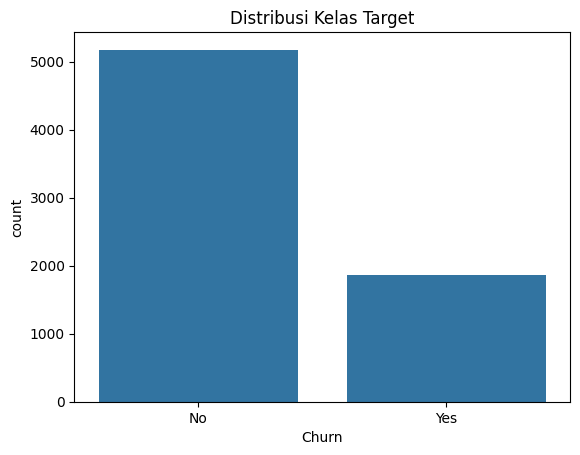

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df['Churn'].value_counts(normalize=True))
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

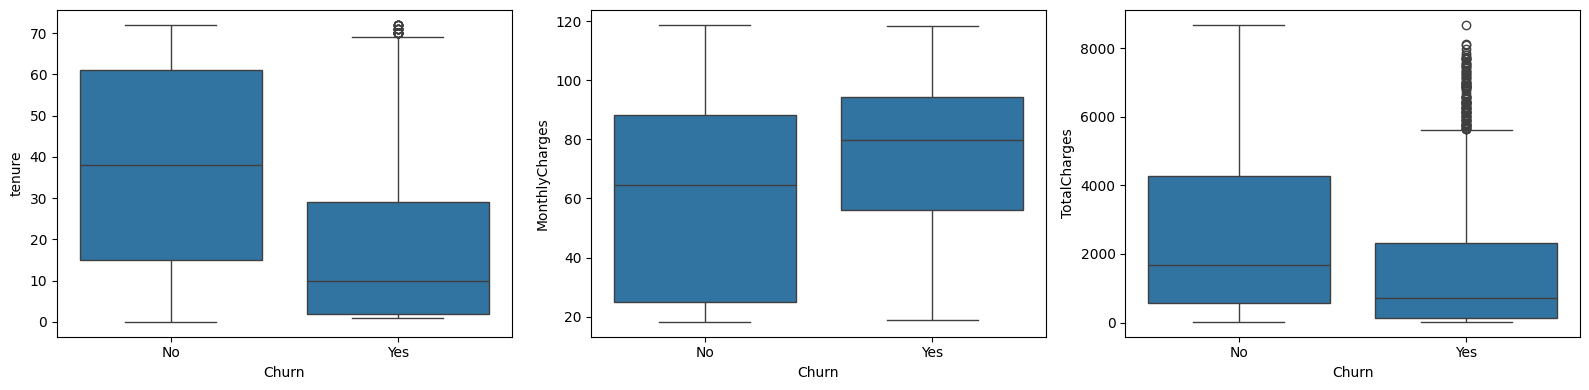

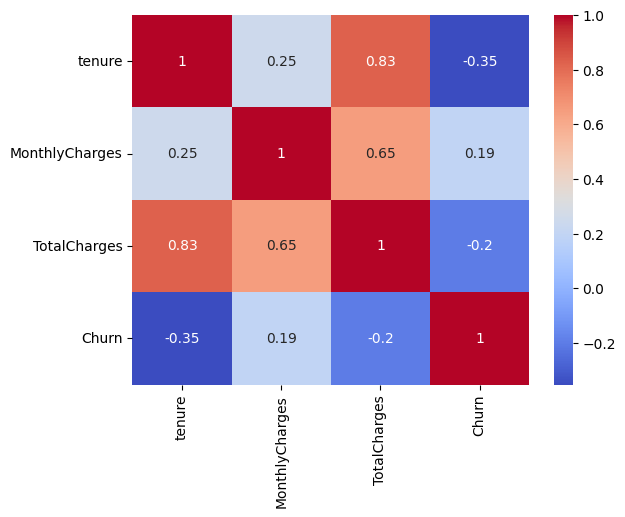

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=c, ax=ax)
plt.tight_layout()
plt.show()

sns.heatmap(df[num_cols].assign(Churn=(df['Churn'] == 'Yes').astype(int)).corr(), annot=True, cmap='coolwarm')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

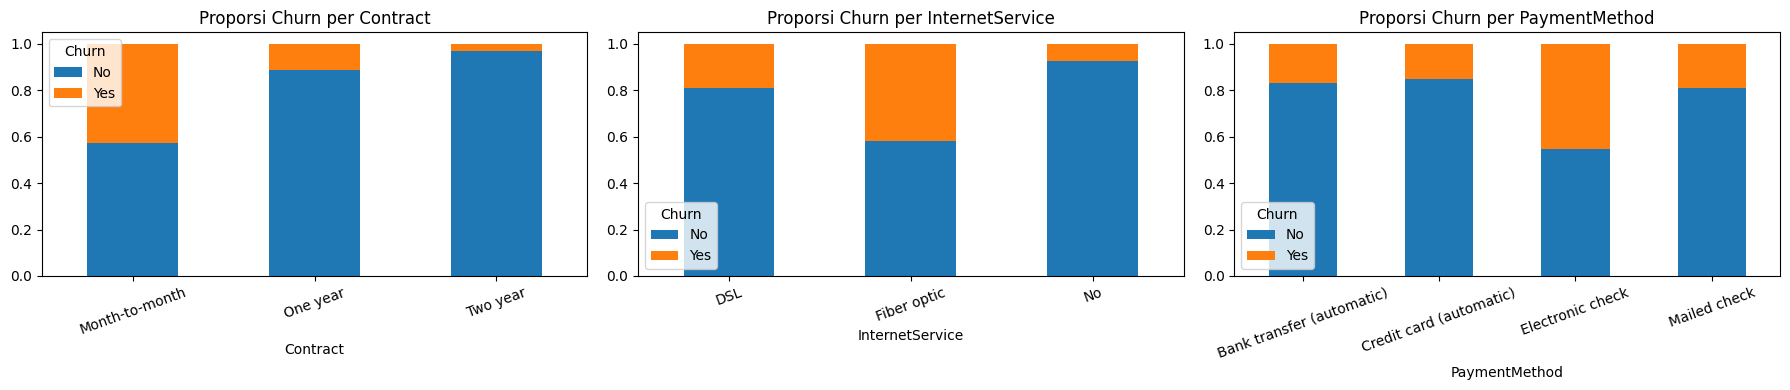

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, c in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    pd.crosstab(df[c], df['Churn'], normalize='index').plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'Proporsi Churn per {c}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# 11 baris TotalCharges kosong semuanya memiliki tenure=0 (pelanggan baru, belum pernah ditagih),
# sehingga diisi 0. Nilai ini berasal dari logika domain, bukan statistik data, jadi tidak ada leakage.
print(df.loc[df['TotalCharges'].isnull(), 'tenure'].unique())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

[0]


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df = df.drop(columns='customerID')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.shape

(7043, 31)

In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns='Churn')
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [9]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [10]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred = mlp.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, y_pred))

Test Accuracy: 0.7970191625266146


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [12]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
act_models = {a: MLPClassifier(hidden_layer_sizes=(10,), activation=a, max_iter=500, random_state=42).fit(X_train, y_train)
              for a in activations}

In [13]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
act_df = pd.DataFrame({'Activation': activations,
                       'Train Acc': [accuracy_score(y_train, act_models[a].predict(X_train)) for a in activations],
                       'Test Acc': [accuracy_score(y_test, act_models[a].predict(X_test)) for a in activations]})
best_act = act_df.loc[act_df['Test Acc'].idxmax(), 'Activation']
print('Activation terbaik:', best_act)
act_df

Activation terbaik: logistic


,Activation,Train Acc,Test Acc
0,relu,0.817004,0.797019
1,tanh,0.822506,0.786373
2,logistic,0.806177,0.801278


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [14]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
sizes = [(2,), (5,), (10,), (50,), (100, 50), (200, 100, 50)]
size_models = {s: MLPClassifier(hidden_layer_sizes=s, activation=best_act, max_iter=500, random_state=42).fit(X_train, y_train)
               for s in sizes}

In [15]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = [accuracy_score(y_train, size_models[s].predict(X_train)) for s in sizes]
test_acc = [accuracy_score(y_test, size_models[s].predict(X_test)) for s in sizes]
size_df = pd.DataFrame({'Arsitektur': [str(s) for s in sizes], 'Train Acc': train_acc, 'Test Acc': test_acc})
size_df

,Arsitektur,Train Acc,Test Acc
0,"(2,)",0.803337,0.799148
1,"(5,)",0.806887,0.797729
2,"(10,)",0.806177,0.801278
3,"(50,)",0.807242,0.806246
4,"(100, 50)",0.806354,0.803407
5,"(200, 100, 50)",0.806354,0.802697


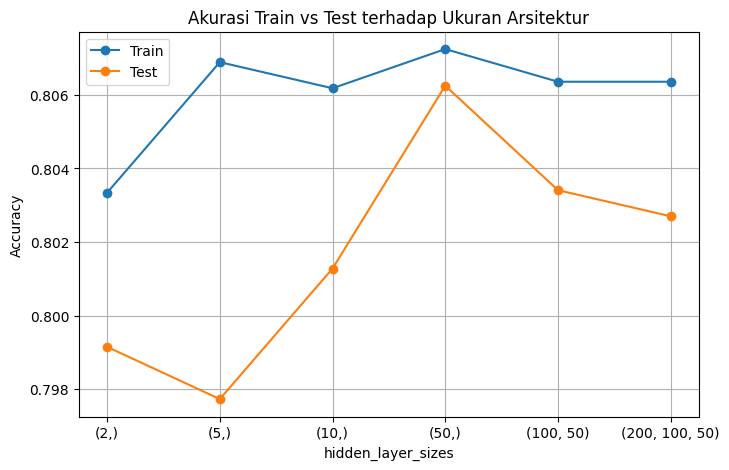

In [16]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(size_df['Arsitektur'], train_acc, 'o-', label='Train')
plt.plot(size_df['Arsitektur'], test_acc, 'o-', label='Test')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.title('Akurasi Train vs Test terhadap Ukuran Arsitektur')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
best_size = sizes[int(np.argmax(test_acc))]
best_models = {f'Aktivasi terbaik ({best_act}, (10,))': act_models[best_act],
               f'Arsitektur terbaik ({best_act}, {best_size})': size_models[best_size]}

def metrik(m):
    p = m.predict(X_test)
    return [accuracy_score(y_test, p), precision_score(y_test, p), recall_score(y_test, p), f1_score(y_test, p)]

pd.DataFrame({k: metrik(m) for k, m in best_models.items()}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

,Accuracy,Precision,Recall,F1-Score
"Aktivasi terbaik (logistic, (10,))",0.801278,0.651613,0.540107,0.590643
"Arsitektur terbaik (logistic, (50,))",0.806246,0.662379,0.550802,0.601460


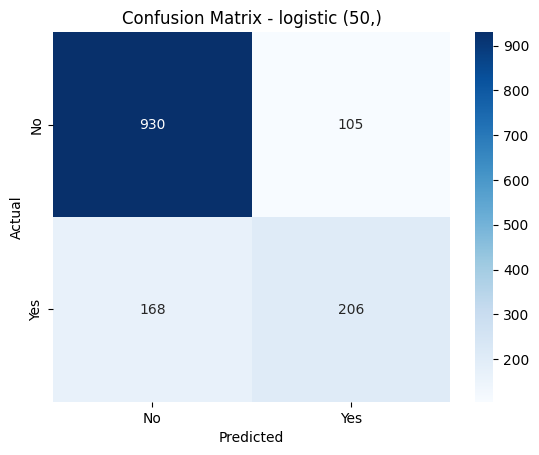

In [18]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
best_model = size_models[best_size]
sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test)), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix - {best_act} {best_size}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

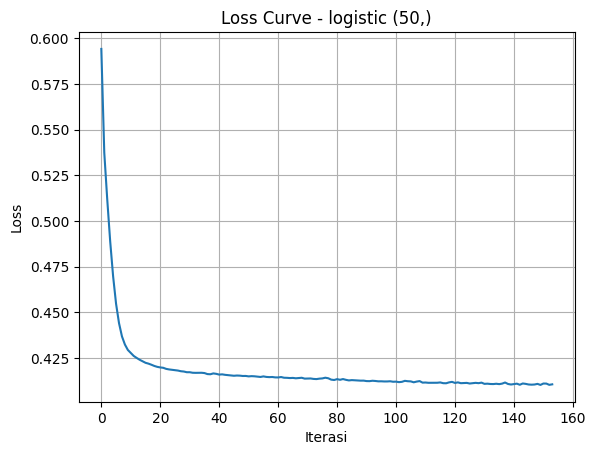

Jumlah iterasi: 154 | max_iter: 500


In [19]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title(f'Loss Curve - {best_act} {best_size}')
plt.grid(True)
plt.show()
print('Jumlah iterasi:', best_model.n_iter_, '| max_iter:', best_model.max_iter)

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Perbandingan fungsi aktivasi.** Dengan arsitektur yang sama `(10,)`, ketiga aktivasi menghasilkan akurasi test yang mirip: ReLU 79.7%, Tanh 78.6%, dan Logistic 80.1%. Selisih terbesar hanya ~1.5%, sehingga tidak signifikan. Namun polanya menarik: Tanh punya akurasi train tertinggi (82.3%) tetapi test terendah, ReLU di tengah (81.7% / 79.7%), sedangkan Logistic punya akurasi train terendah (80.6%) tetapi test tertinggi dengan celah train-test terkecil (<1%). Hal ini karena gradien sigmoid kecil (maksimal 0.25) dan mudah jenuh, sehingga bobot berubah lebih pelan dan model cenderung membentuk batas keputusan yang lebih halus (tidak menghafal noise). Sebaliknya ReLU dan Tanh memiliki gradien lebih besar sehingga lebih cepat menyesuaikan diri dengan data train. Perbedaannya kecil karena dataset Telco sebagian besar berisi fitur dummy biner dengan pola yang relatif sederhana (contoh dari EDA: churn sangat dipengaruhi `Contract`, `tenure`, dan `InternetService`), sehingga semua aktivasi mencapai batas performa yang hampir sama (~80%). Sebagai acuan, menebak semua pelanggan "No" saja sudah memberi akurasi 73.5%.

**Eksperimen ukuran arsitektur.** Dengan aktivasi Logistic, akurasi train hampir konstan di 80.3–80.7% dan akurasi test di 79.8–80.6% untuk semua arsitektur dari `(2,)` hingga `(200, 100, 50)`. Akurasi test terbaik dicapai `(50,)` sebesar 80.6%. Pada eksperimen ini **tidak terlihat gejala overfitting yang jelas**: kurva train tidak terus naik dan celah train-test tetap di bawah 1% walaupun jumlah neuron dan layer ditambah. Ciri overfitting yang seharusnya terlihat pada grafik (kurva train terus naik mendekati 100% sementara kurva test stagnan/turun) tidak muncul karena (1) gradien sigmoid yang kecil membuat jaringan sulit menghafal data, dan (2) training dihentikan otomatis ketika loss tidak lagi turun lebih dari `tol` selama 10 iterasi berturut-turut, sehingga model besar justru berhenti lebih cepat. Mulai arsitektur `(100, 50)` akurasi test sedikit menurun (80.3%) tanpa kenaikan akurasi train, yang menunjukkan kapasitas tambahan tidak memberi manfaat lagi.

**Evaluasi model terbaik.** Model terbaik (Logistic, `(50,)`) memiliki Accuracy 80.6%, Precision 66.2%, Recall 55.1%, dan F1 0.601. Recall yang rendah menunjukkan hampir separuh pelanggan yang benar-benar churn (168 dari 374) gagal terdeteksi. Ini akibat dataset imbalanced (26.5% churn), sehingga model condong memprediksi kelas mayoritas "No".

**Loss curve.** Loss turun tajam pada iterasi awal lalu melandai, dan training berhenti di iterasi ke-154, jauh sebelum `max_iter=500`. Artinya model sudah konvergen (perbaikan loss sudah lebih kecil dari `tol`). Jika loss curve masih menurun tajam saat `max_iter` tercapai, model belum konvergen sehingga langkah yang dilakukan adalah menaikkan `max_iter`, memperbesar `learning_rate_init`, atau memastikan fitur sudah di-scaling dengan benar.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
1. ANN mencapai akurasi test ~80%, di atas baseline kelas mayoritas (73.5%).
2. Perbedaan fungsi aktivasi tidak signifikan, dan Logistic sedikit unggul (80.1%).
3. Menambah ukuran arsitektur tidak meningkatkan performa. Arsitektur terbaik `(50,)` dengan akurasi 80.6%.
4. Model sudah konvergen, tetapi Recall churn masih rendah (55.1%) akibat data imbalanced.

**Saran:**
- Tangani imbalance data dengan SMOTE atau threshold yang lebih rendah.
- Tuning hyperparameter (`hidden_layer_sizes`, `alpha`, `activation`) dengan `GridSearchCV`.